In [1]:
from sklearn.datasets import make_regression
import numpy as np

In [2]:
x , y = make_regression(n_samples=4, n_features=1, n_informative=1,
                        n_targets=1, noise=80, random_state=13)

In [3]:
x

array([[-0.71239066],
       [ 0.45181234],
       [-0.04450308],
       [ 0.75376638]])

In [4]:
y

array([  7.21786552,  16.04609925, -27.83756166, 144.36688189])

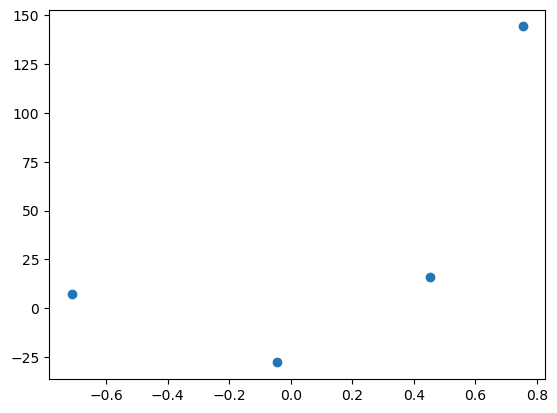

In [5]:
import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.show()

In [6]:
# Let's apply OLS
from sklearn.linear_model import LinearRegression

In [7]:
reg = LinearRegression()
reg.fit(x,y)

LinearRegression()

In [8]:
LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, positive=False)

LinearRegression()

In [9]:
reg.coef_

array([78.35063668])

In [10]:
reg.intercept_

np.float64(26.15963284313262)

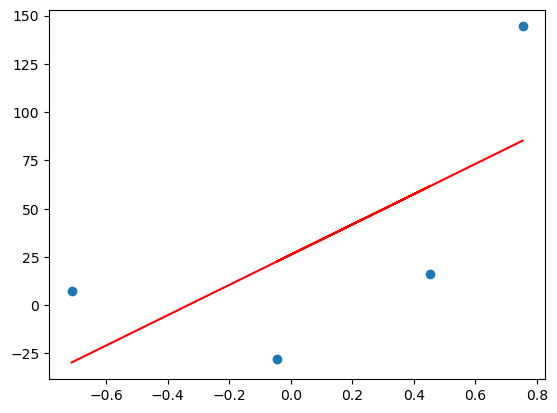

In [11]:
plt.scatter(x,y)
plt.plot(x, reg.predict(x), color='red')

In [12]:
# let's apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0
y_pred = ((78.35*x) + 100).reshape(4)

In [13]:
y_pred

array([ 44.18419163, 135.39949674,  96.51318381, 159.05759577])

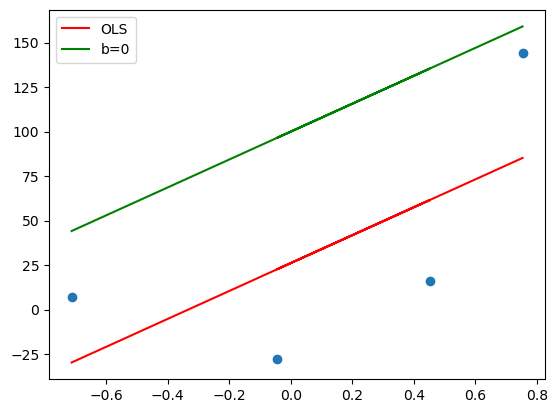

In [14]:
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red',label='OLS')
plt.plot(x, y_pred,color='green', label='b=0')
plt.legend()
plt.show()

In [15]:
m = 78.35
b = 100

loss_slope = -2*np.sum(y - m*x.ravel() - b)
loss_slope

np.float64(590.7223659179078)

In [16]:
# lets take learning rate = 0.1
lr = 0.1

step_size = loss_slope*lr
step_size

np.float64(59.072236591790784)

In [17]:
# calculating the new intercept
b = b - step_size
b

np.float64(40.927763408209216)

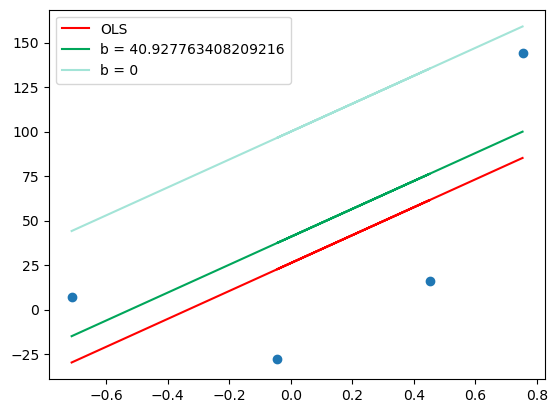

In [18]:
y_pred1 = ((78.35*x) + b).reshape(4)

plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red',label='OLS')
plt.plot(x,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(x,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [19]:
loss_slope = -2*np.sum(y - m*x.ravel() - b)
loss_slope

np.float64(118.14447318358157)

In [20]:
step_size = loss_slope*lr
step_size

np.float64(11.814447318358157)

In [21]:
b = b - step_size
b

np.float64(29.11331608985106)

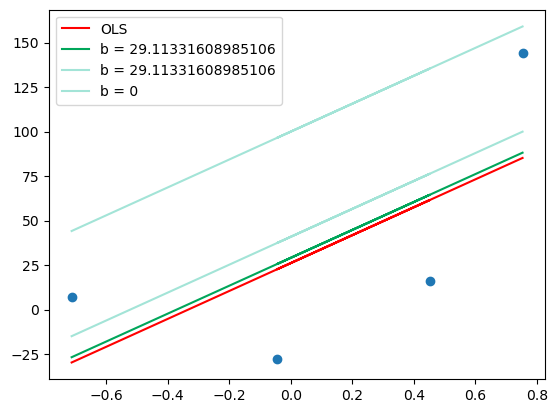

In [22]:
y_pred2 = ((78.35*x) + b).reshape(4)

plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red',label='OLS')
plt.plot(x,y_pred2,color='#00a65a',label='b = {}'.format(b))
plt.plot(x,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(x,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [23]:
# Iteration 3
loss_slope = -2 * np.sum(y - m*x.ravel() - b)
loss_slope

np.float64(23.62889463671634)

In [24]:


step_size = loss_slope*lr
step_size

np.float64(2.362889463671634)

In [25]:
b = b - step_size
b

np.float64(26.750426626179426)

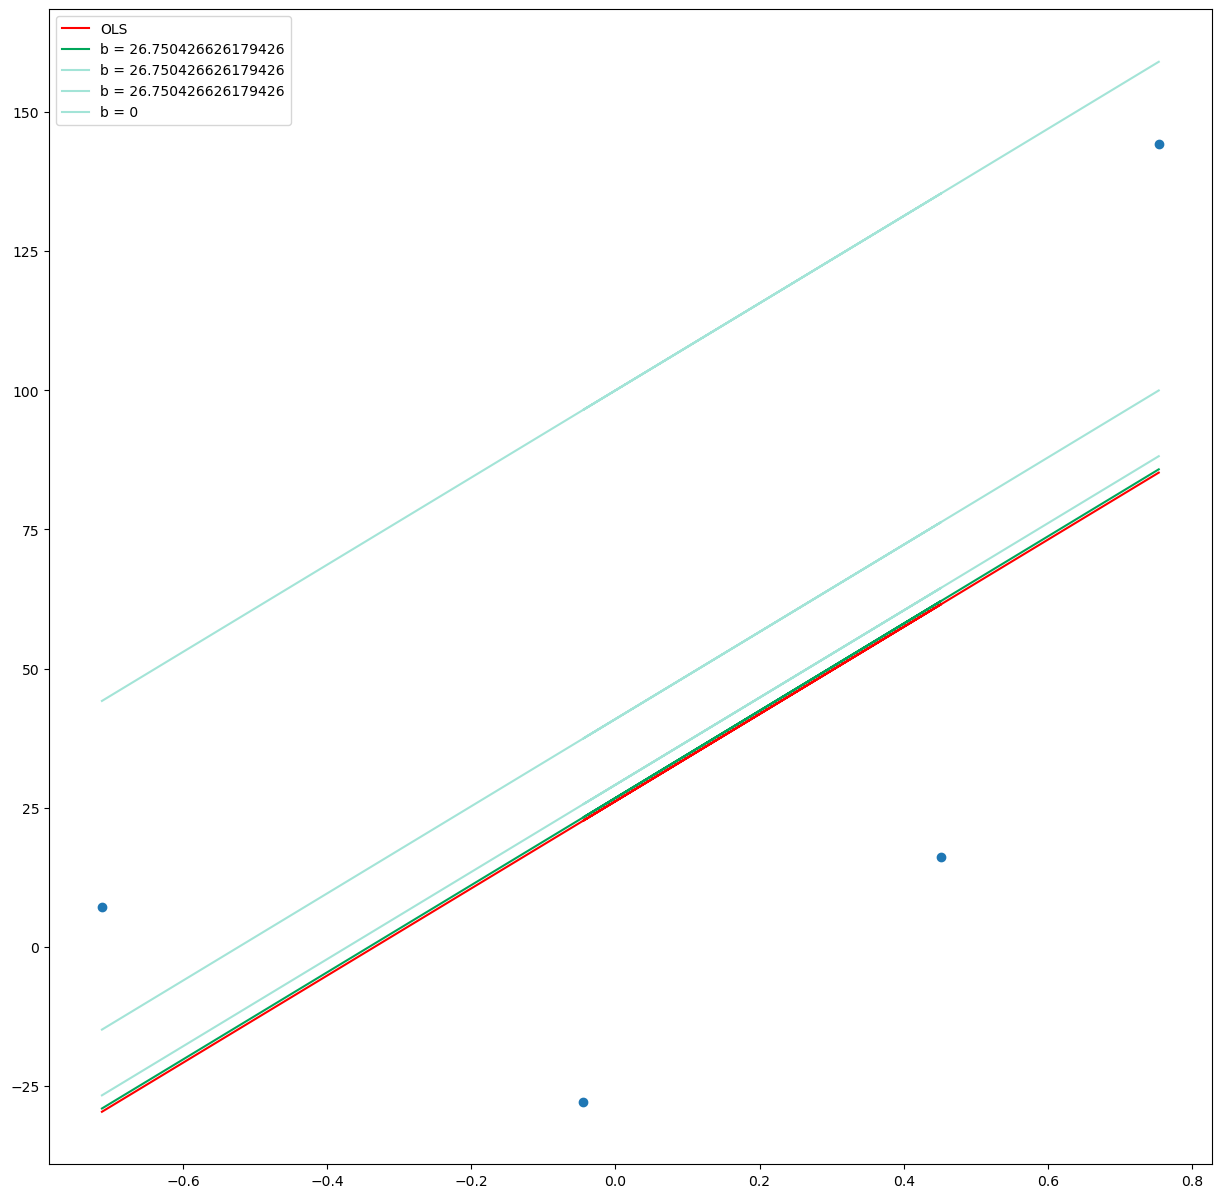

In [26]:
y_pred3 = ((78.35 * x) + b).reshape(4)

plt.figure(figsize=(15,15))
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red',label='OLS')
plt.plot(x,y_pred3,color='#00a65a',label='b = {}'.format(b))
plt.plot(x,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(x,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(x,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

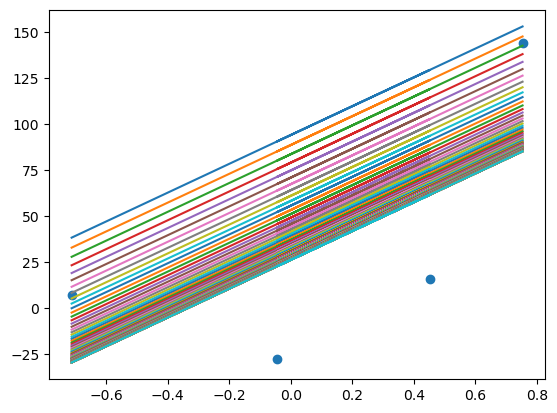

In [27]:
b = 100
m = 78.35
lr = 0.01

epochs = 100

for i in range(epochs):
    loss_slope = -2*np.sum(y - m*x.ravel() - b)
    b = b - (lr*loss_slope)

    y_pred = m*x + b

    plt.plot(x, y_pred)

plt.scatter(x,y)

In [28]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [29]:
x , y = make_regression(n_samples=100,n_features=1, n_informative=1,
                        n_targets=1,noise=20,random_state=13)

In [30]:
x

array([[-0.71239066],
       [-0.43714566],
       [-0.45375238],
       [ 0.95283061],
       [ 0.23785784],
       [ 0.86121137],
       [-0.24332625],
       [ 0.18494595],
       [-0.72099967],
       [-0.42989708],
       [ 2.01522083],
       [ 0.39724133],
       [ 0.20780005],
       [-0.23242587],
       [-0.76862702],
       [ 0.45315861],
       [ 0.63988397],
       [ 0.3595323 ],
       [-1.61510796],
       [ 1.74924179],
       [-0.78898902],
       [-0.51196509],
       [-0.92833523],
       [ 2.15038297],
       [-0.2073497 ],
       [-1.63909341],
       [-0.33861825],
       [-0.32212366],
       [-0.48137142],
       [-0.52316421],
       [ 0.72196506],
       [ 0.76591105],
       [ 0.45348104],
       [-1.26160595],
       [-2.18711527],
       [-1.18541881],
       [ 0.21745166],
       [ 1.33031692],
       [-1.08718159],
       [ 0.56226171],
       [-1.51284512],
       [-0.00238903],
       [-0.27813452],
       [ 0.45181234],
       [ 1.19070527],
       [ 0

In [31]:
y

array([-3.43198806e+01, -9.42120961e+00, -1.90881877e+01,  2.04372122e+01,
        2.77559659e+01, -2.90750046e+00, -1.41987828e+01,  5.40025891e+00,
       -2.64264302e+01, -3.49067872e+01,  3.73362043e+01,  1.28532816e+01,
        2.50289888e+01, -1.89608736e+01, -2.34655852e+01,  3.77839324e+01,
        6.69670792e+00, -5.57201352e+00, -4.92158778e+01,  1.59474399e+01,
       -4.29667324e+01,  6.09015466e+00, -2.53194769e+01,  6.28216706e+01,
        1.24870400e+01, -3.27136530e+01, -1.88255476e+01, -2.93912926e+01,
       -2.86886731e+01,  4.38924069e+00,  4.63542396e+01,  2.43919519e+01,
        3.79848517e+01, -3.45767718e+01, -6.18736296e+01, -4.64421597e+01,
       -6.88808416e+00,  3.96988084e+01, -3.52373298e+01,  8.36850884e+00,
       -3.96814412e+01,  8.27318308e+00, -4.40722161e+00, -3.01350607e+00,
        5.78213629e+01,  2.46525603e+01,  1.81131707e+01, -5.22849035e+01,
        3.59187182e+01,  1.58411788e+01,  2.40080546e+01, -2.51245994e+01,
       -4.39284313e+01,  

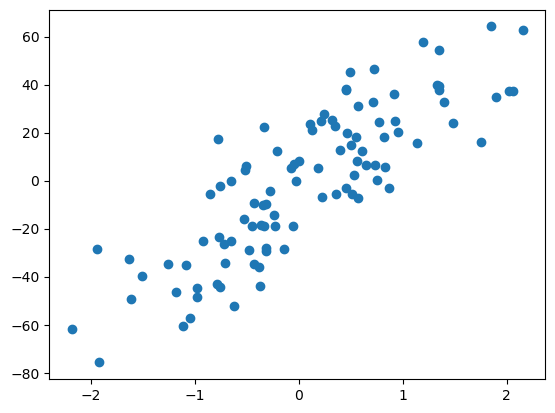

In [32]:
plt.scatter(x,y)

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
x_train , x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [35]:
from sklearn.linear_model import LinearRegression

In [36]:
lr = LinearRegression()

In [37]:
lr.fit(x_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.2710144261783816


In [38]:
y_pred = lr.predict(x_test)

In [39]:
from sklearn.metrics import r2_score

In [40]:
r2_score(y_test,y_pred)

0.6345158782661013

In [41]:
class GDRegressor:

    def __init__(self,learning_rate,epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,x,y):
        # calculate the b using GD
        for i in range(epochs):
            loss_slope_b = -2*np.sum(y - self.m*x.ravel()-self.b)
            loss_slope_m = -2*np.sum((y - self.m*x.ravel()-self.b)*x.ravel())

            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
        print(self.m,self.b)

    def predict(self,x):
        return self.m*x + self.b

In [42]:
gd = GDRegressor(0.001,50)

In [43]:
gd.fit(x_train,y_train)

28.12598618006269 -2.2710234077993587


In [44]:
y_pred = gd.predict(x_test)

In [45]:
from sklearn.metrics import r2_score

In [46]:
r2_score(y_test,y_pred)

0.634515826773629

# Animations

In [47]:
from IPython.display import Javascript
%matplotlib inline

In [48]:
from sklearn.datasets import make_regression

%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [49]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1,
                      n_targets=1,noise=20,random_state=13)

In [50]:
plt.scatter(X,y)
plt.show()

<IPython.core.display.Javascript object>

In [51]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

[27.82809103]
-2.29474455867698


In [52]:
b = -150
m = 27.82
lr = 0.001
all_b = []
all_cost = []

epochs = 30

for i in range(epochs):
    slope = 0
    cost = 0
    for j in range(X.shape[0]):
        slope = slope - 2*(y[j] - (m * X[j]) -  b)
        cost = cost + (y[j] - m * X[j] -b) ** 2

    b = b - (lr * slope)
    all_b.append(b)
    all_cost.append(cost)
    y_pred = m * X + b
    plt.plot(X,y_pred)
plt.scatter(X,y)

<IPython.core.display.Javascript object>

In [53]:
all_b = np.array(all_b).ravel()

In [54]:
all_b

array([-120.4588544 ,  -96.82593791,  -77.91960473,  -62.79453818,
        -50.69448494,  -41.01444235,  -33.27040827,  -27.07518102,
        -22.11899921,  -18.15405376,  -14.98209741,  -12.44453232,
        -10.41448025,   -8.7904386 ,   -7.49120528,   -6.45181862,
         -5.62030929,   -4.95510183,   -4.42293586,   -3.99720308,
         -3.65661686,   -3.38414789,   -3.16617271,   -2.99179256,
         -2.85228845,   -2.74068515,   -2.65140252,   -2.57997641,
         -2.52283553,   -2.47712282])

In [55]:
all_cost = np.array(all_cost).ravel()
all_cost

array([2210040.49020261, 1424629.13499295,  921965.86765877,
        600261.37656489,  394370.50226481,  262600.34271276,
        178267.44059944,  124294.38324692,   89751.62654131,
         67644.26224972,   53495.5491031 ,   44440.37268926,
         38645.05978441,   34936.0595253 ,   32562.29935947,
         31043.09285334,   30070.80068942,   29448.5337045 ,
         29050.28283416,   28795.40227714,   28632.27872065,
         28527.87964449,   28461.06423575,   28418.30237416,
         28390.93478274,   28373.41952423,   28362.20975879,
         28355.0355089 ,   28350.44398898,   28347.50541622])

In [56]:
fig, ax = plt.subplots(figsize=(9,5))
#fig.set_tight_layout(True)

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m -150
ax.scatter(X, y)
line, = ax.plot(x_i, x_i*50 - 4, 'r-', linewidth=2)

def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m + all_b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=epochs, interval=500)

#f = r"animation.gif" 
#writergif = animation.PillowWriter(fps=2) 
#anim.save(f, writer=writergif)

<IPython.core.display.Javascript object>

In [57]:
# creating a blank window 
# for the animation 
fig = plt.figure(figsize=(9,5)) 
axis = plt.axes(xlim =(0, 31), ylim =(0, 2500000)) 
  
line, = axis.plot([], [], lw = 2) 
  
xdata, ydata = [], [] 
  
# animation function 
def animate(i): 
    label = 'epoch {0}'.format(i + 1)
    xdata.append(num_epochs[i]) 
    ydata.append(all_cost[i]) 
    line.set_data(xdata, ydata) 
    axis.set_xlabel(label)
      
    return line, 
  
# calling the animation function     
anim = animation.FuncAnimation(fig, animate, frames = 30,repeat=False, interval = 500)

f = r"animation1.gif" 
writergif = animation.PillowWriter(fps=2) 
anim.save(f, writer=writergif)

<IPython.core.display.Javascript object>

IndexError: list index out of range

In [ ]:
fig = plt.figure(figsize=(9,5)) 
axis = plt.axes(xlim =(0, 31), ylim =(-150, 0)) 
  
line, = axis.plot([], [], lw = 2) 
  
xdata, ydata = [], [] 
  
# animation function 
def animate(i): 
    label = 'epoch {0}'.format(i + 1)
    xdata.append(num_epochs[i]) 
    ydata.append(all_b[i]) 
    line.set_data(xdata, ydata) 
    axis.set_xlabel(label)
      
    return line, 
  
# calling the animation function     
anim = animation.FuncAnimation(fig, animate, frames = 30,repeat=False, interval = 500)

f = r"animation2.gif" 
writergif = animation.PillowWriter(fps=2) 
anim.save(f, writer=writergif)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation
import numpy as np

fig, ax = plt.subplots()
ax.plot(all_b, all_cost)
x, y = [],[]
sc = ax.scatter(x,y,color='red',marker='+')
plt.xlim(-150,50)
plt.ylim(0,2500000)

def animate(i):
    label = 'epoch {0}'.format(i + 1)
    x.append(all_b[i])
    y.append(all_cost[i])
    sc.set_offsets(np.c_[x,y])
    ax.set_xlabel(label)

ani = matplotlib.animation.FuncAnimation(fig, animate, 
                frames=30, interval=500, repeat=True) 
plt.show()

f = r"animation3.gif" 
writergif = animation.PillowWriter(fps=2) 
ani.save(f, writer=writergif)

In [ ]:
b_input = np.linspace(-150,150,100)

In [ ]:
cost_input = []

for i in range(len(b_input)):
    this_cost = 0 
    for j in range(X.shape[0]):
        this_cost = this_cost + (y[j] - m*X[j] - b_input[i])**2
    #cost_input.append(this_cost)
    print(this_cost)